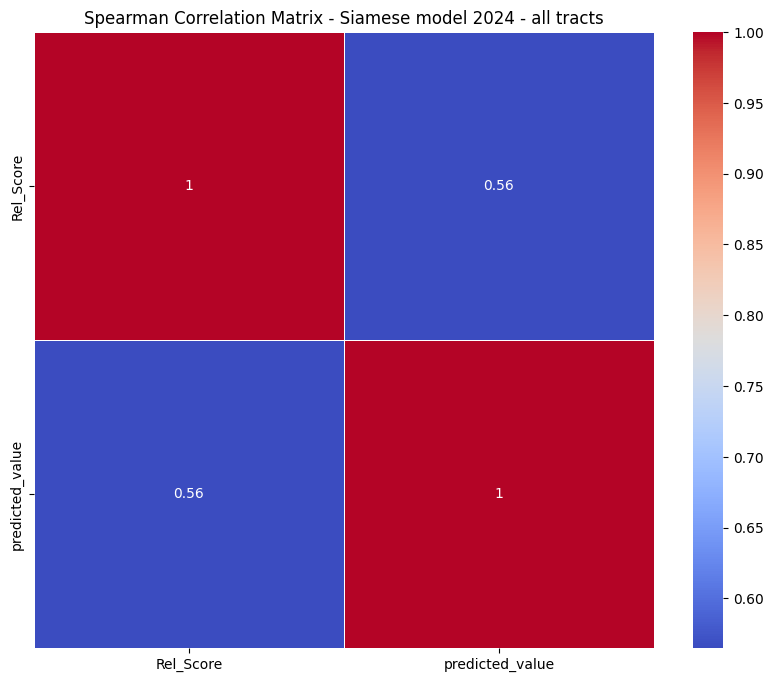

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_correlation_matrix(df, title, method='spearman'):
    """
    Plots a correlation matrix for the given DataFrame.

    Parameters:
    df (pd.DataFrame): The input DataFrame for which to plot the correlation matrix.
    title (str): The title of the plot.

    Returns:
    None: Displays the correlation matrix plot.
    """
    # Calculate the correlation matrix
    corr_matrix = df.corr(method=method)

    # Set up the matplotlib figure
    plt.figure(figsize=(10, 8))

    # Draw the heatmap with seaborn
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=.5)

    # Set the title of the plot
    plt.title(title)

    # Show the plot
    plt.show()

df_abs_2024 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024\predictions_2024.parquet")
df_siam_2024 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024_siam\predictions_2024.parquet")
df_siam_2016 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024_siam\predictions_2016.parquet")

plot_correlation_matrix(df_siam_2024[["Rel_Score", "predicted_value"]], "Spearman Correlation Matrix - Siamese model 2024 - all tracts")

In [68]:
df_tract_siam_2016.GEOID.dtype

dtype('int64')

In [63]:
tracts

,GEOID,geometry,type
0,36047036001,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\t\x00\x...",test
1,36047061002,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\r\x00\x...",test
2,36047036002,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\n\x00\x...,test
3,36047035602,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\r\x00\x...,test
4,36047036200,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x0e\x00...,test
...,...,...,...
2267,36005044902,"b""\x01\x03\x00\x00\x00\x01\x00\x00\x00\n\x00\x...",train
2268,36119001503,b'\x01\x06\x00\x00\x00\x02\x00\x00\x00\x01\x03...,train
2269,36119001403,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x0c\x00...,train
2270,36119001505,b'\x01\x06\x00\x00\x00\x03\x00\x00\x00\x01\x03...,train


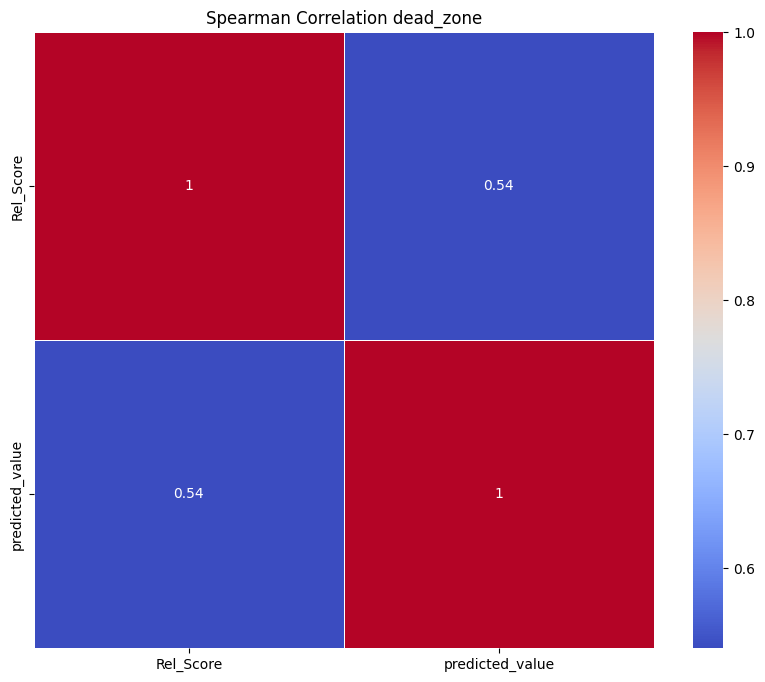

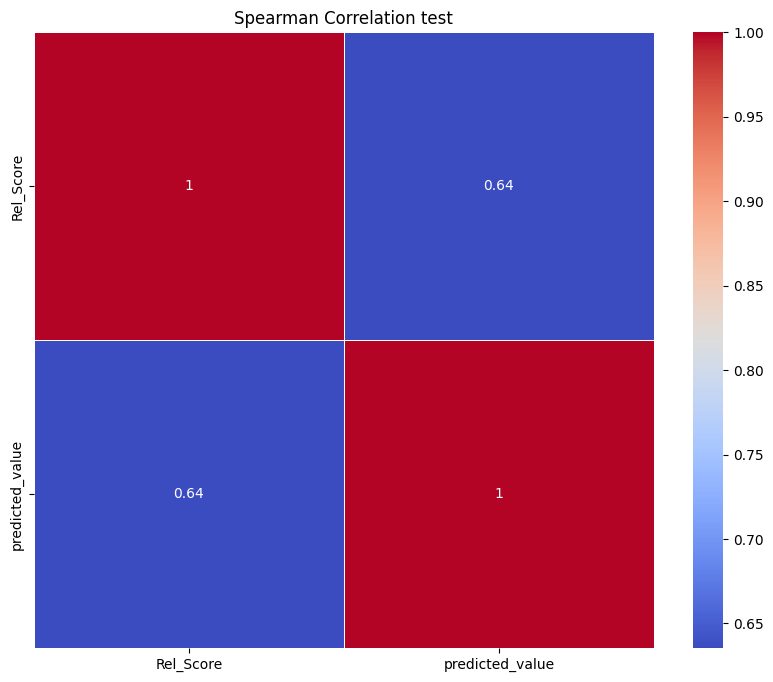

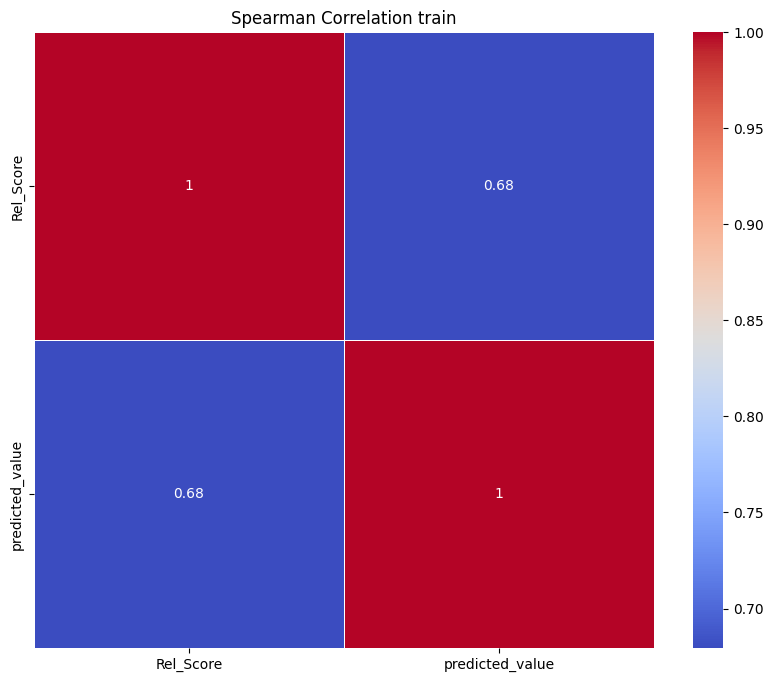

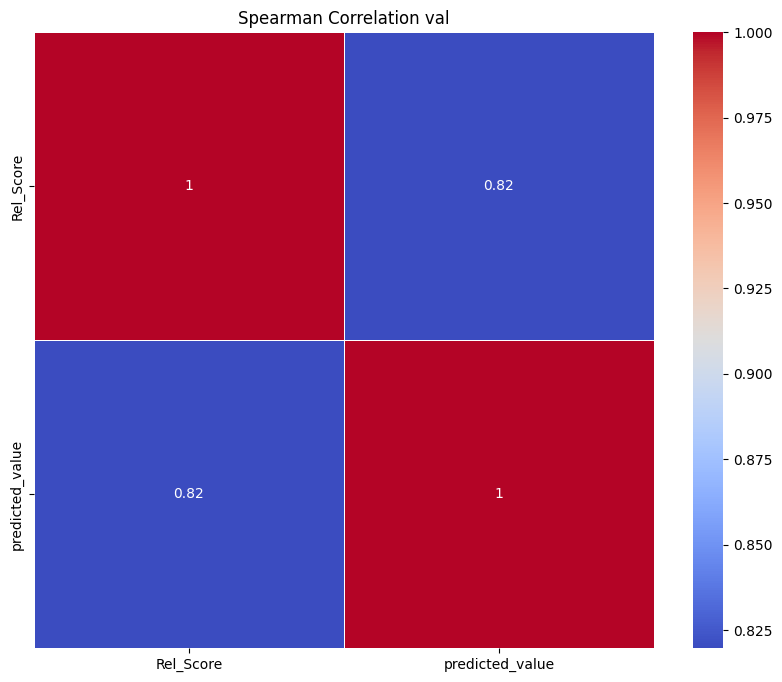

C:\Users\abbat\AppData\Local\Temp\ipykernel_22792\112855475.py:4: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



""


In [72]:
df_tract_siam_2016 = pd.read_parquet(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\results\scalemae_lr5e-05_size224_y2010-2012-2014-2016-2018-2020-2022-2024_siam\predictions_by_tract_2024.parquet")
tracts = pd.read_feather(r"C:\Working Papers\NY State Aerial Imagery Prototype\ny_state_aerial_imagery_prototype\data\processed\tract_splits.feather")
tracts["GEOID"] = tracts["GEOID"].astype(int)
tracts.merge(df_tract_siam_2016, on="GEOID").groupby("type").apply(lambda x: plot_correlation_matrix(x[["Rel_Score", "predicted_value"]], f"Spearman Correlation {x['type'].iloc[0]}"))

In [60]:
df_tract_siam_2016

,GEOID,Rel_Score,predicted_value,predicted_value_std
0,36005000100,-3.680874,-0.364980,0.165818
1,36005000200,-0.239422,-0.189412,0.136372
2,36005000400,0.224346,-0.168950,0.103754
3,36005001600,-0.620740,-0.361656,0.092613
4,36005001901,-0.864956,-0.260860,0.123378
...,...,...,...,...
2295,36119002600,-0.103110,-0.050558,0.160686
2296,36119002900,-0.758583,-0.563756,0.055438
2297,36119003000,-0.760140,-0.318709,0.077308
2298,36119003500,-0.673080,-0.244300,NaN


(-3.0, 3.0)

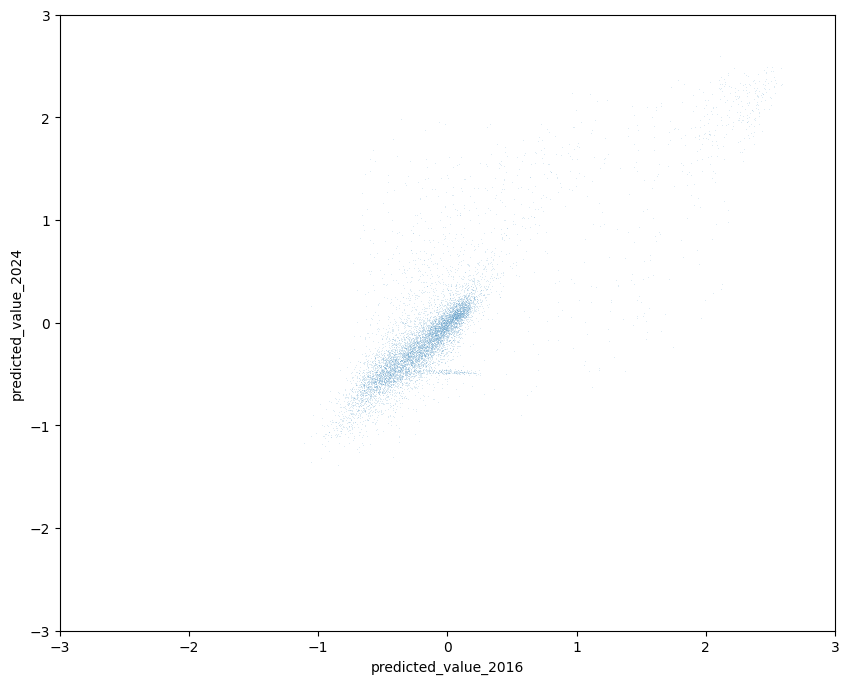

In [54]:
df_plot = df_siam_2024.merge(df_siam_2016, on="DOITT_ID", suffixes=("_2024", "_2016"))
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(x="predicted_value_2016", y="predicted_value_2024", data=df_plot.sample(10000), s=0.1, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

In [ ]:
import plotly.express as px

df_plot = df_siam_2024.merge(df_siam_2016, on="DOITT_ID", suffixes=("_2024", "_2016"))
fig = px.density_heatmap(df_plot, x="predicted_value_2024", y="predicted_value_2016")
# fig.update_xaxes(range=[-3, 3])
# fig.update_yaxes(range=[-3, 3])
fig.show()

(-3.0, 3.0)

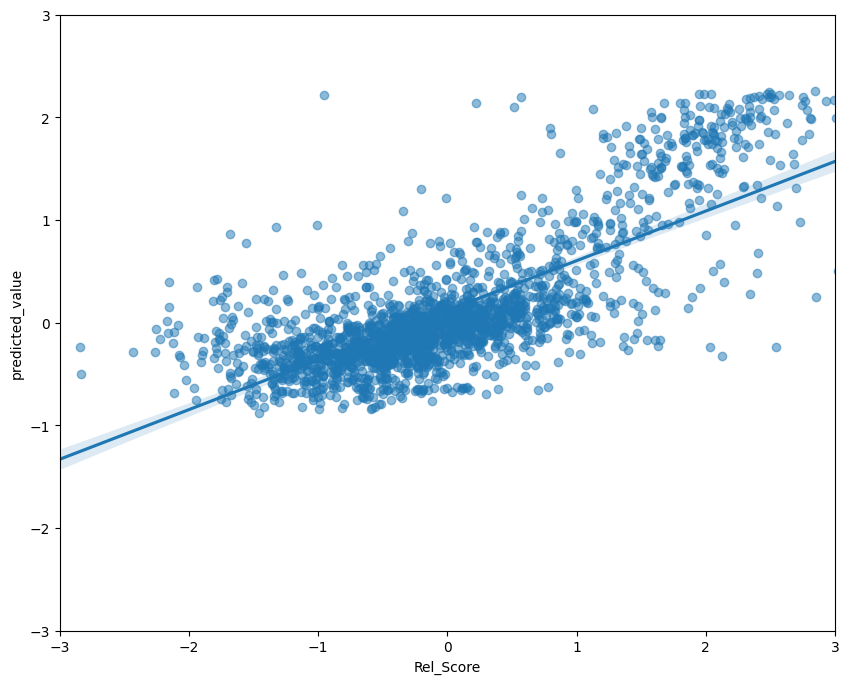

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.regplot(x="Rel_Score", y="predicted_value", data=df_abs_2024.groupby("GEOID").agg({"Rel_Score": "mean", "predicted_value": "mean"}), scatter_kws={'alpha':0.5}, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)